In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)
from pathlib import Path

In [2]:
processed_data_dir = Path("../data/processed")
results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

In [3]:
y_train = pd.read_csv(processed_data_dir / "y_train.csv").values.ravel()
y_val   = pd.read_csv(processed_data_dir / "y_val.csv").values.ravel()
y_test  = pd.read_csv(processed_data_dir / "y_test.csv").values.ravel()

In [4]:
models = ["lr", "fnn", "rnn", "lstm"]

preds = {}
for m in models:
    preds[m] = pd.read_csv(f"{processed_data_dir}/{m}_ytest_pred.csv").values.ravel()

In [5]:
results = []

for m in models:
    y_pred = preds[m]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": m.upper(),
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,LR,0.991150,0.988450,0.994654,0.991542
1,FNN,0.988362,0.985457,0.992329,0.988881
2,RNN,0.484301,0.766667,0.016039,0.031421
3,LSTM,0.989574,0.989549,0.990470,0.990009


In [6]:
results_df.to_csv(results_dir / "model_comparison.csv", index=False)

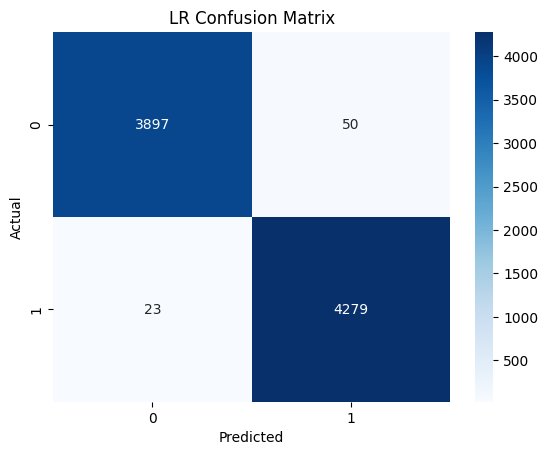

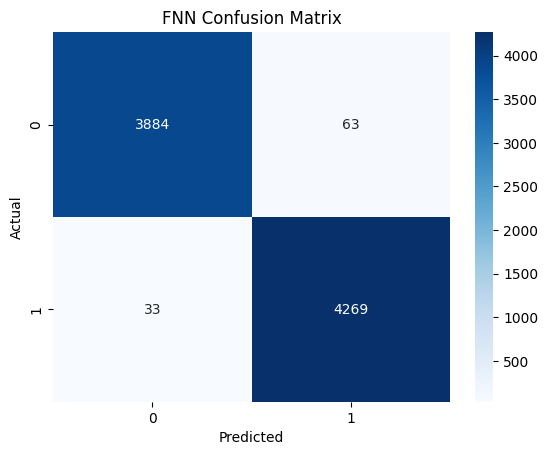

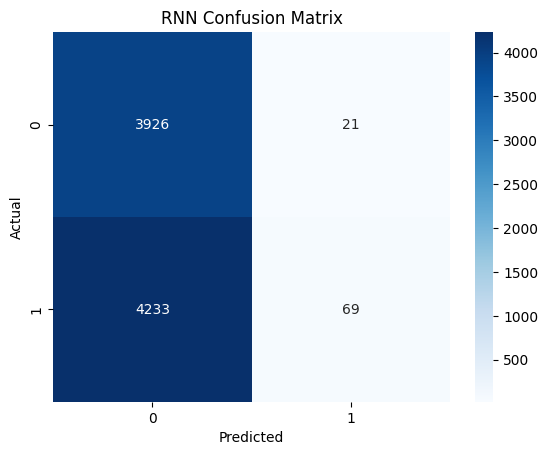

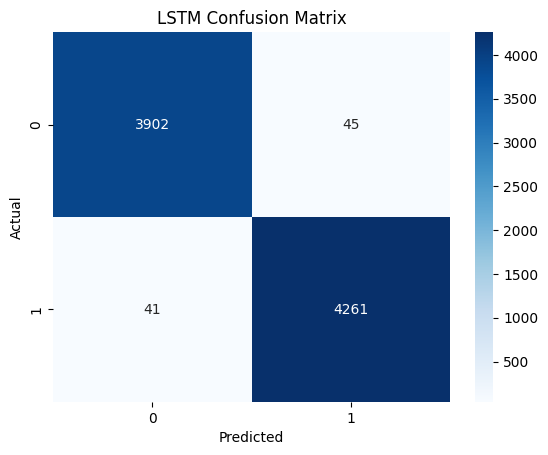

In [7]:
def plot_conf_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.savefig(f"{results_dir}/{model_name}_confusion_matrix.png")
    plt.show()

for m in models:
    plot_conf_matrix(y_test, preds[m], m.upper())

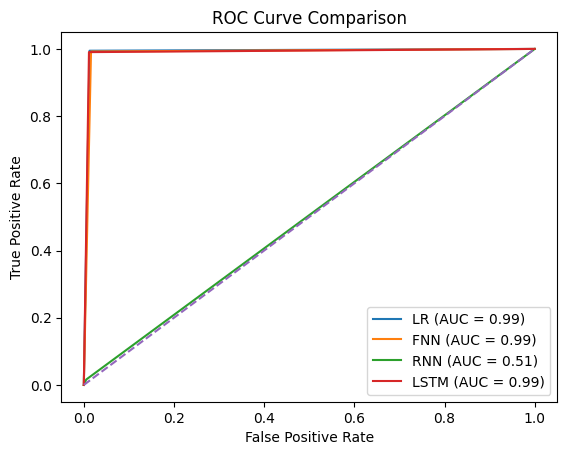

In [8]:
fpr_dict = {}
tpr_dict = {}
auc_dict = {}

plt.figure()

for m in models:
    y_pred = preds[m]

    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{m.upper()} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.savefig(f"{results_dir}/roc_curve.png")
plt.show()